# Structure of the document

1. Import and Define Parameters
2. Load pre and post as seperate cubes, compute dNBR locally
3. Failed Approaches to calculate dNBR in openEO
4. Failed Approaches to load and index both images in one cube

## 1. Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [54]:
import matplotlib.pyplot as plt
from PIL import Image
import openeo
from openeo.processes import array_create, if_, and_
from openeo.api.process import Parameter
# OpenEO UDP parameter management system
from openeo_udp import ParameterManager

import rasterio

### Define Parameters and Connect to OpenEO Backend

Load algorithm parameters from the co-located parameter file and connect to an OpenEO backend with automatic endpoint selection.

In [55]:
source = 'eopf' # OR cde
if source == 'eopf':
    connection = openeo.connect(
        url="https://api.explorer.eopf.copernicus.eu/openeo"
    ).authenticate_oidc_authorization_code()

    current_params = {
            "location_name": "Forest, North Portugal",
            "bounding_box": Parameter(
                "bounding_box",
                description="Spatial extent for Venice Lagoon",
                default= {"west": -7.987061, "south": 40.012891, "east": -7.434998,"north": 40.359103}
            ),
            "time": Parameter(
                "time",
                description="Temporal range for data acquisition",
                # default=["2025-10-15", "2025-10-16"], # + last
                default=["2025-07-25", "2025-07-31"],  # + last
            ),
            "bands": Parameter(
                "bands",
                description="Sentinel-2 bands required for APA calculation",
                default=["reflectance|b02", "reflectance|b03", "reflectance|b04", "reflectance|b08","reflectance|b8a", "reflectance|b11", "reflectance|b12"]
#,
            ),
            "collection": Parameter(
                "collection",
                description="Data collection identifier",
                default="sentinel-2-l2a",
            ),
            "cloud_cover": Parameter(
                "cloud_cover",
                description="Maximum cloud cover percentage",
                default=30,
            ),
        }


time_post= ["2025-10-15", "2025-10-16"]
time_pre = ["2025-07-25", "2025-07-31"]


if source == 'cde':
    connection = openeo.connect(
        url="https://api.explorer.eopf.copernicus.eu/openeo"
    ).authenticate_oidc_authorization_code()

    current_params = {
            "location_name": "Forest, North Portugal",
            "bounding_box": Parameter(
                "bounding_box",
                description="Spatial extent for Venice Lagoon",
                default= {
    "west": -7.987061,
    "south": 40.012891,
    "east": -7.434998,
    "north": 40.359103}
    ),
            "time": Parameter(
                "time",
                description="Temporal range for data acquisition",
                # default=["2025-10-15", "2025-10-16"], # + last
                default=["2025-07-25", "2025-07-31"],  # + last
            ),
            "bands": Parameter(
                "bands",
                description="Sentinel-2 bands required for APA calculation",
                default=["B02", "B03", "B04", "B05", "B08", "B8A", "B11", "B12"]
#,
            ),
            "collection": Parameter(
                "collection",
                description="Data collection identifier",
                default="SENTINEL2_L2A",
            ),
            "cloud_cover": Parameter(
                "cloud_cover",
                description="Maximum cloud cover percentage",
                default=30,
            ),
        }


## 2. Calculate dNBR by loading pre and post image seperatley



In [56]:
# First define functions to use for loading image and calculating NBR

def load_and_sample(params, time):
    """
    Input: Set of parameters and relevant time
    Output: Cube that contains the last image on a res of 100
    """ 
    s2cube = connection.load_collection(
    params["collection"].default,
    temporal_extent=time,
    spatial_extent=params["bounding_box"].default,
    bands=params["bands"].default,
    # properties={
    #     "eo:cloud_cover": lambda x: x <= params["cloud_cover"].default,
    # },
    )
    s2cube = s2cube.reduce_dimension(dimension="time", reducer="last")

    s2cube = s2cube.resample_spatial(
        resolution=[100, 100],
      method="near",
    )

    return s2cube
    

def calculate_nbr(data):
     """ 
     Input: Cube
     Output: NBR
     """
     B08, B12 = (
          data[3],
          data[6],
     )
     nbr = (B08 - B12) / (B08 + B12)
     return nbr

In [57]:
# Load Satellite image before and after the fire as cubes
s2cube_pre = load_and_sample(current_params, time_pre)
s2cube_post = load_and_sample(current_params, time_post)

In [ ]:
# Calculate NBR for each of them
nbr_post = s2cube_post.apply_dimension(dimension="bands", process=calculate_nbr)
nbr_pre = s2cube_pre.apply_dimension(dimension="bands", process=calculate_nbr)

In [59]:
# Download and save nbrs

nbr_pre_tiff = nbr_pre.save_result("GTIFF")
nbr_post_tiff = nbr_post.save_result("GTIFF")

connection.download(
    {"process_graph": nbr_pre_tiff.flat_graph()},
    "nbr_pre.tif"
)

connection.download(
    {"process_graph": nbr_post_tiff.flat_graph()},
    "nbr_post.tif"
)

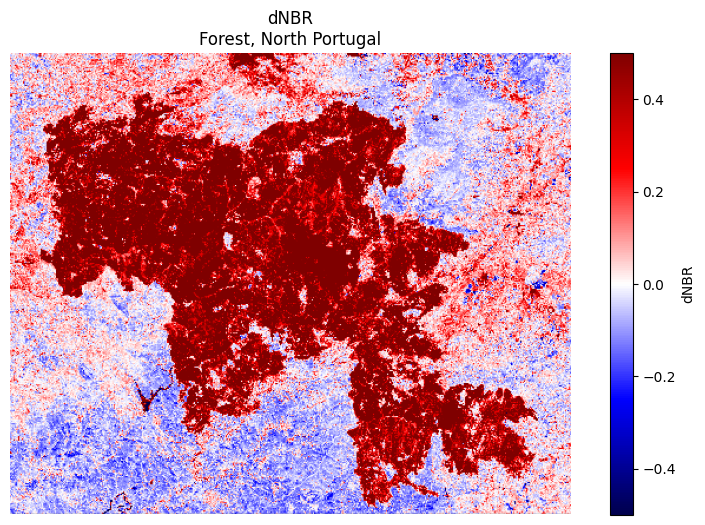

In [60]:
# Open NBRs and calculate dNBR and visualize it
with rasterio.open("nbr_pre.tif") as src:
    pre = src.read(1).astype("float32")

with rasterio.open("nbr_post.tif") as src:
    post = src.read(1).astype("float32")

dnbr = pre - post

plt.figure(figsize=(10, 6))
plt.imshow(dnbr, cmap="seismic", vmin=-0.5, vmax=0.5)
plt.colorbar(label="dNBR")
plt.title(f"dNBR\n{current_params['location_name']}")
plt.axis("off")
plt.show()

In [ ]:
dnbr_mask = dnbr > 0.1

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(dnbr, cmap="seismic", vmin=-0.5, vmax=0.5)
axes[0].set_title(f"dNBR\n{current_params['location_name']}")
axes[0].axis("off")

axes[1].imshow(dnbr_mask, cmap="gray")
axes[1].set_title("dNBR > 0.1 mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 3. Merging the cubes to perform the dNBR calculation on the server side failed

In [67]:
from openeo.processes import subtract
dnbr = subtract(nbr_pre,nbr_post)

In [68]:
# Define function for testing
def test(dnbr):
    dnbr_vis = dnbr.linear_scale_range(-1, 1, 0, 255)
    dnbr_png = dnbr_vis.save_result("PNG")

    filename = f"apa_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.png"
    connection.download(
    {
        "process_graph": dnbr_png.flat_graph(),
    },
    filename,
)

In [69]:
test(dnbr)

OpenEoApiError: [500] ServerError: unsupported operand type(s) for -: 'RasterStack' and 'RasterStack'

### Merge Cubes is not available (in eopf)

In [70]:
dnbr = nbr_pre.merge_cubes(nbr_post, overlap_resolver="subtract")

In [71]:
test(dnbr)

Preflight process graph validation raised: [ProcessUnsupported] Process 'merge_cubes' not found in registry


OpenEoApiError: [500] ServerError: 'Process merge_cubes not found in namespace predefined!'

### Apply dimension fails because of a cube/pixel missmatch (?)

In [65]:
def calculate_dnbr(data, pre):
    return data - pre

dnbr_result = nbr_post.apply_dimension(dimension='bands', process=lambda data: calculate_dnbr(data, nbr_pre))
dnbr = dnbr_result 

In [ ]:
test(dnbr)

OpenEoApiError: [500] ServerError: unsupported operand type(s) for -: 'float' and 'RasterStack'

## 4. Approach 2: Load Both images in one cube

In [91]:
s2cube_both = connection.load_collection(
    "sentinel-2-l2a",
    temporal_extent=["2025-07-25", "2025-10-16"],  # full range
    spatial_extent=current_params["bounding_box"].default,
    bands=current_params["bands"].default,
)
s2cube_both = s2cube_both.resample_spatial(resolution=[100, 100], method="near")

# Apply NBR to get time series
nbr_timeseries = s2cube_both.apply_dimension(dimension="bands", process=calculate_nbr)

#### Custom Reducer - Return dnbr
I would like to index nbr_timeseries [0] and [-1] (first and last element to perform calculation)
However, this seems to fail because I can not index -1, is there another way for me to find the last element?

In [92]:
def dnbr_reducer(data):
    # data is the time series of NBR values
    first_nbr = data[0]
    last_nbr = data[-1]
    dnbr =  first_nbr - last_nbr
    return dnbr

# Reduce time dimension with your custom reducer (returns single image)
dnbr = nbr_timeseries.reduce_dimension(dimension="time", reducer=dnbr_reducer)

In [93]:
test(dnbr)

OpenEoApiError: [500] ServerError: Index value must be >= 0, -1

Testing if this works for first and second image

In [94]:
def dnbr_reducer(data):
    # data is the time series of NBR values
    first_nbr = data[0]
    second_nbr = data[1]
    dnbr =  first_nbr - second_nbr
    return dnbr

# Reduce time dimension with your custom reducer (returns single image)
dnbr = nbr_timeseries.reduce_dimension(dimension="time", reducer=dnbr_reducer)


In [95]:
test(dnbr)

OpenEoApiError: [500] ServerError: index 1 is out of bounds for axis 0 with size 1

It doesnt work, only has a size 1, does that mean I am indexing wrongly? How can I access the correct images?
Inspecting the cube, but I dont understand what it means

In [84]:
nbr_timeseries